In [1]:
import numpy as np
import scipy.io as sio
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path

FS = 12_000

In [4]:
mat_file = Path("../data/normal/97.mat")
mat = sio.loadmat(mat_file, squeeze_me=True)

for key, value in mat.items():
    if not key.startswith("__"):
        print(f"Key: '{key}'  |  Typ: {type(value).__name__}  | Shape: {getattr(value, 'shape', '_')}")

Key: 'X097_DE_time'  |  Typ: ndarray  | Shape: (243938,)
Key: 'X097_FE_time'  |  Typ: ndarray  | Shape: (243938,)
Key: 'X097RPM'  |  Typ: int  | Shape: _


In [5]:
# Extracting Signal
signal_normal = mat["X097_DE_time"].astype(np.float64)

print(f"Length:              {len(signal_normal)} Samples")
print(f"Duration:            {len(signal_normal) / FS:.2f} Sekunden")
print(f"Min / Max:           {signal_normal.min():.4f} / {signal_normal.max():.4f}")
print(f"Average:             {signal_normal.mean():.6f}")
print(f"standard deviation:  {signal_normal.std():.6f}")

Length:              243938 Samples
Duration:            20.33 Sekunden
Min / Max:           -0.2866 / 0.3113
Average:             0.012558
standard deviation:  0.072687


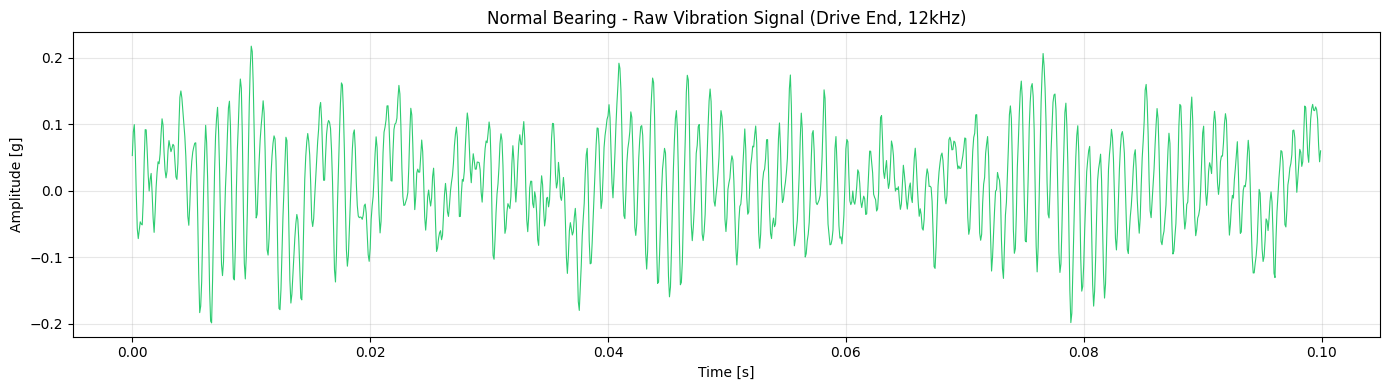

In [9]:
t = np.arange(len(signal_normal)) / FS

plot_samples = int(0.1 * FS)

plt.figure(figsize=(14, 4))
plt.plot(t[:plot_samples], signal_normal[:plot_samples], color="#2ecc71", linewidth=0.8)

plt.title("Normal Bearing - Raw Vibration Signal (Drive End, 12kHz)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [g]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

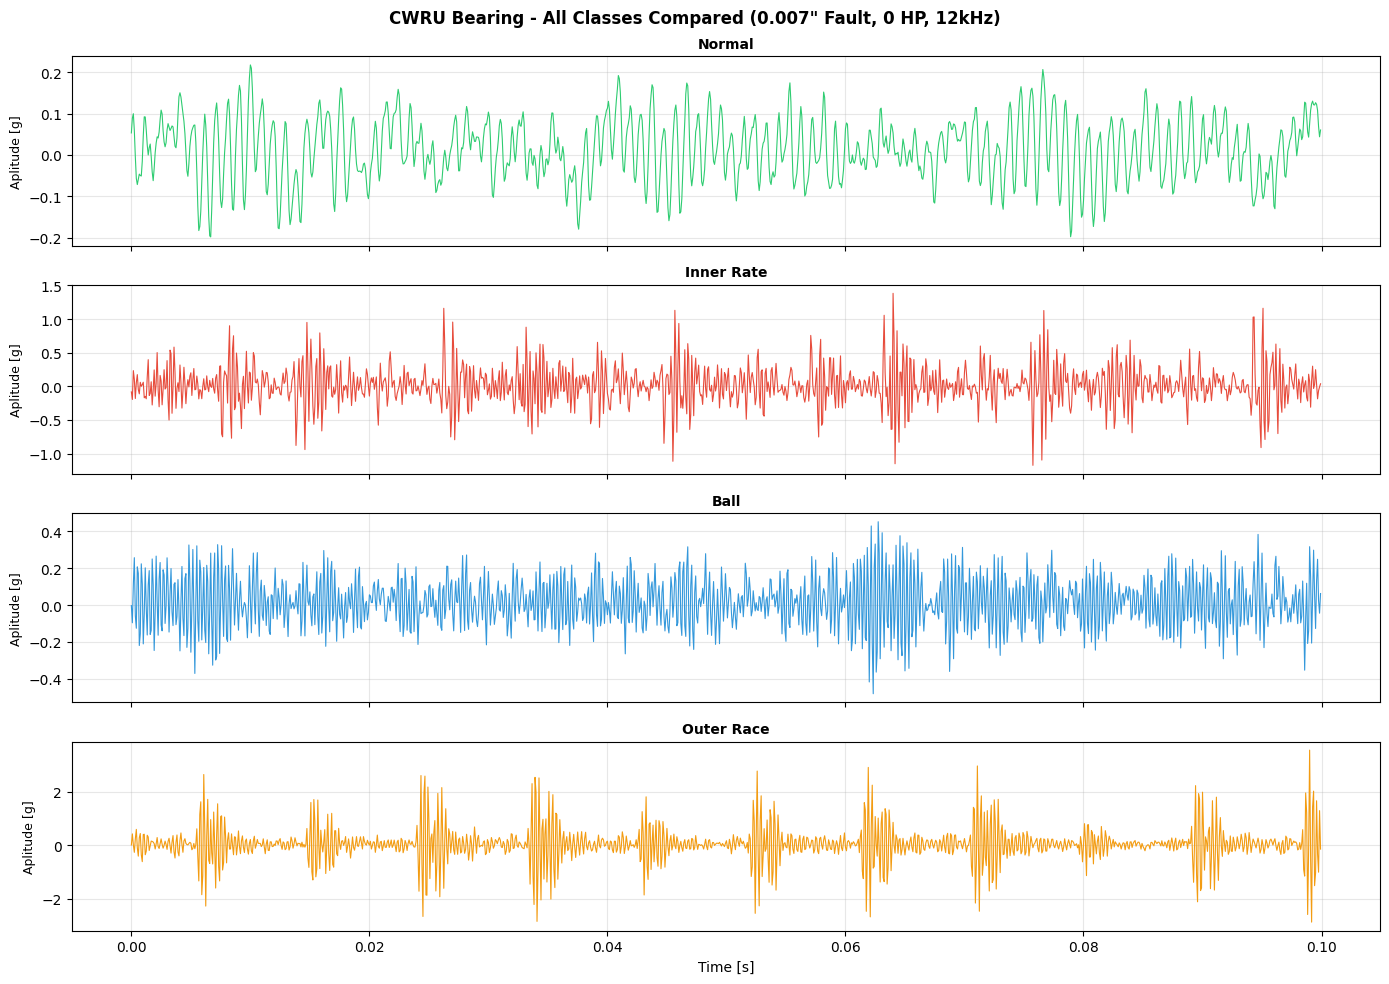

In [16]:
def get_de_signal(path: str) -> np.ndarray:
    """Load .mat file and automatically extract the Drive End signal."""
    mat = sio.loadmat(Path(path), squeeze_me=True)
    de_keys = [k for k in mat.keys() if "DE" in k and "time" in k]
    if not de_keys:
        raise KeyError(f"No DE key found in {path}. Available: {list(mat.keys())}")
    return mat[de_keys[0]].astype(np.float64)

#Load all four signals
signals = {
    "Normal": (get_de_signal("../data/normal/97.mat"), "#2ecc71"),
    "Inner Race": (get_de_signal("../data/12k drive end/105.mat"), "#e74c3c"),
    "Ball": (get_de_signal("../data/12k drive end/118.mat"), "#3498db"),
    "Outer Race": (get_de_signal("../data/12k drive end/130.mat"), "#f39c12")
}

#Plot first 0.1s for all four
plot_samples = int(0.1 * FS)
t = np.arange(plot_samples) / FS

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, (name, (sig, color)) in zip(axes, signals.items()):
    ax.plot(t, sig[:plot_samples], color=color, linewidth=0.8)
    ax.set_ylabel("Aplitude [g]", fontsize=9)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("CWRU Bearing - All Classes Compared (0.007\" Fault, 0 HP, 12kHz)",
            fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()